# Classifieur de Validité des Phrases de Trajet

Ce notebook entraîne un classifieur binaire pour détecter si une phrase est **valide** (contient une intention de trajet) ou **invalide** (hors contexte).

## Objectif
Créer un système qui filtre les phrases avant le traitement NLP, permettant de ne traiter que les phrases pertinentes.

## Structure
1. **Configuration & Imports** - Paramètres centralisés et dépendances
2. **Chargement des Données** - Lecture et exploration du dataset
3. **Preprocessing** - Nettoyage et vectorisation
4. **Entraînement avec Checkpoints** - Modèles avec sauvegarde périodique
5. **Évaluation** - Métriques et analyse des erreurs
6. **Sauvegarde du Modèle Final** - Export pour production


## 1. Configuration & Imports

### Configuration centralisée

**Objectif** : Définir tous les paramètres en un seul endroit pour faciliter les expérimentations.

**Ce qu'on fait** :
- Définir les chemins vers les fichiers et dossiers (dataset, modèles, résultats, checkpoints)
- Configurer les paramètres du dataset (limite, seed pour reproductibilité)
- Définir comment diviser les données (train/validation/test)
- Configurer le preprocessing TF-IDF (comment transformer le texte en nombres)
- Choisir le type de modèle et ses hyperparamètres
- Activer/désactiver les checkpoints

**Pourquoi** : Avoir tous les paramètres au même endroit permet de modifier facilement l'expérience sans chercher dans tout le code.


In [1]:
# ============================================================================
# CONFIGURATION - Modifier ces paramètres selon vos besoins
# ============================================================================

import os
from pathlib import Path
from datetime import datetime

# Chemins des fichiers
# Dans un notebook Jupyter, le répertoire courant est généralement le dossier du notebook
# Le notebook est dans classifier/notebooks/, on remonte de 2 niveaux pour accéder à la racine du projet
import os
PROJECT_ROOT = Path(os.getcwd()).parent.parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
# Utiliser les dossiers spécifiques au classifieur
DATASET_PATH = PROJECT_ROOT / "dataset" / "classifier" / "json" / "dataset.jsonl"
MODELS_DIR = PROJECT_ROOT / "classifier" / "models"
CHECKPOINTS_DIR = PROJECT_ROOT / "classifier" / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "classifier" / "results"
LOGS_DIR = PROJECT_ROOT / "classifier" / "logs" / "training"

# Créer les dossiers si nécessaire
for dir_path in [MODELS_DIR, CHECKPOINTS_DIR, RESULTS_DIR, LOGS_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

# Paramètres du dataset
DATASET_LIMIT = None  # None pour utiliser tout le dataset, ou int pour limiter
RANDOM_SEED = 42

# Paramètres de split
TEST_SIZE = 0.2
VAL_SIZE = 0.1  # Proportion du train qui devient validation
STRATIFY = True  # Maintenir la distribution des classes

# Paramètres de preprocessing
LOWERCASE = False  # Garder la casse pour préserver les variations
MIN_DF = 2  # Minimum document frequency pour TF-IDF
MAX_DF = 0.95  # Maximum document frequency
MAX_FEATURES = 10000  # Nombre maximum de features TF-IDF
NGRAM_RANGE = (1, 2)  # Unigrammes et bigrammes

# Paramètres d'entraînement
MODEL_TYPE = "logistic_regression"  # Options: "logistic_regression", "svm", "random_forest", "gradient_boosting"
SAVE_CHECKPOINTS = True  # Activer les checkpoints
CHECKPOINT_INTERVAL = 0.1  # Sauvegarder tous les 10% de l'entraînement (pour cross-validation)
EARLY_STOPPING = True  # Early stopping (arrêter si plus d'amélioration)
EARLY_STOPPING_PATIENCE = 3  # Nombre d'itérations sans amélioration avant d'arrêter
SAVE_FINAL_MODEL = True  # Sauvegarder automatiquement le modèle final (False pour éviter la sauvegarde lors de "Run All")
MODELS_TO_TRAIN = [
       "logistic_regression",
       "svm",
       "random_forest",
       "gradient_boosting"
   ]
# Paramètres spécifiques par modèle
MODEL_CONFIGS = {
    "logistic_regression": {
        "C": 1.0,
        "max_iter": 1000,
        "solver": "lbfgs",
        "class_weight": "balanced"  # Gérer le déséquilibre des classes
    },
    "svm": {
        "C": 1.0,
        "kernel": "linear",
        "class_weight": "balanced"
    },
    "random_forest": {
        "n_estimators": 100,
        "max_depth": 20,
        "class_weight": "balanced",
        "random_state": RANDOM_SEED
    },
    "gradient_boosting": {
        "n_estimators": 100,
        "learning_rate": 0.1,
        "max_depth": 5,
        "random_state": RANDOM_SEED
    }
}

# Métadonnées
EXPERIMENT_NAME = f"validity_classifier_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
VERSION = "v1"

print(f"✅ Configuration chargée")
print(f"   Dataset: {DATASET_PATH}")
print(f"   Modèle: {MODEL_TYPE}")
print(f"   Expérience: {EXPERIMENT_NAME}")


✅ Configuration chargée
   Dataset: /workspace/dataset/classifier/json/dataset.jsonl
   Modèle: logistic_regression
   Expérience: validity_classifier_20260106_205631


### Imports

**Objectif** : Charger toutes les bibliothèques nécessaires pour le machine learning et la visualisation.

**Ce qu'on fait** :
- **pandas/numpy** : Manipulation des données (DataFrames, arrays)
- **matplotlib/seaborn** : Création de graphiques et visualisations
- **scikit-learn** : Algorithmes de machine learning (Logistic Regression, SVM, etc.) et outils (train_test_split, métriques)
- **joblib** : Sauvegarde/chargement des modèles entraînés
- **json** : Lecture/écriture de fichiers JSON

**Pourquoi** : Ces bibliothèques fournissent toutes les fonctions nécessaires pour charger les données, entraîner des modèles, évaluer les performances et sauvegarder les résultats.


In [2]:
# Standard libraries
import json
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Essayer différents styles selon la version de matplotlib
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('ggplot')  # Style de fallback
sns.set_palette("husl")

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

# Utilitaires
import joblib
from tqdm import tqdm

print("✅ Imports terminés")


✅ Imports terminés


## 2. Chargement des Données

**Objectif** : Lire le dataset JSONL et le convertir en DataFrame pandas pour pouvoir le manipuler facilement.

**Ce qu'on fait** :
- Créer une fonction `load_jsonl()` qui lit le fichier ligne par ligne
- Chaque ligne du JSONL contient un objet JSON avec : `sentence`, `departure`, `arrival`, `is_valid`
- Convertir toutes les lignes en un DataFrame pandas
- Afficher un aperçu des premières lignes pour vérifier que tout est correct

**Pourquoi** : Le format JSONL (JSON Lines) est pratique pour stocker de grandes quantités de données. Le DataFrame pandas permet ensuite de manipuler facilement les données avec des opérations comme filtrer, grouper, etc.


In [3]:
# Chargement du dataset JSONL
def load_jsonl(file_path, limit=None):
    """Charge un fichier JSONL et retourne un DataFrame."""
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if limit and i >= limit:
                break
            if line.strip():
                data.append(json.loads(line))
    return pd.DataFrame(data)

# Charger les données
print(f"📂 Chargement du dataset depuis {DATASET_PATH}...")
df = load_jsonl(DATASET_PATH, limit=DATASET_LIMIT)
print(f"✅ {len(df)} phrases chargées")

# Afficher les premières lignes
print("\n📊 Aperçu des données:")
print(df.head())


📂 Chargement du dataset depuis /workspace/dataset/classifier/json/dataset.jsonl...
✅ 30000 phrases chargées

📊 Aperçu des données:
                                            sentence            departure  \
0  Je veu alé de Lamothe-Montravel a hoerdt svp c...    Lamothe-Montravel   
1  Quel est le dernier train port de Saint-Amand-...  Saint-Amand-Longpré   
2  Donne-moi les horaires Lyon Saint-Pal PONTHHIÉ...      Lyon Saint-Paul   
3  Je pars de la gare de Mennetu-sur-Cher pour Ép...    Mennetou-sur-Cher   
4                           Je vais à l'université 🚉                 None   

                     arrival  is_valid  
0                     Hoerdt         1  
1             Joué-lès-Tours         1  
2        Ponthierry - Pringy         1  
3  Épinay - Villetaneuse T11         1  
4                       None         0  


### Exploration des données

**Objectif** : Comprendre les caractéristiques du dataset avant de commencer l'entraînement.

**Ce qu'on fait** :
1. **Statistiques de base** : Compter combien de phrases sont valides vs invalides, calculer les pourcentages
2. **Analyse de longueur** : Mesurer la longueur des phrases (moyenne, médiane, min, max) pour voir la variabilité
3. **Visualisations** :
   - Graphique en barres montrant la distribution des classes (valide/invalide)
   - Histogramme montrant la distribution des longueurs de phrases
4. **Exemples** : Afficher quelques exemples de phrases valides et invalides pour comprendre le contenu

**Pourquoi** : Cette exploration permet de :
- Détecter des problèmes (déséquilibre de classes, phrases trop courtes/longues)
- Comprendre la nature des données
- Décider si des ajustements sont nécessaires (par exemple, si les classes sont très déséquilibrées)


📈 Statistiques du dataset:
   Total de phrases: 30000
   Phrases valides (is_valid=1): 20957 (69.9%)
   Phrases invalides (is_valid=0): 9043 (30.1%)

📏 Longueur des phrases:
   Moyenne: 53.8 caractères
   Médiane: 55.0 caractères
   Min: 1 caractères
   Max: 153 caractères


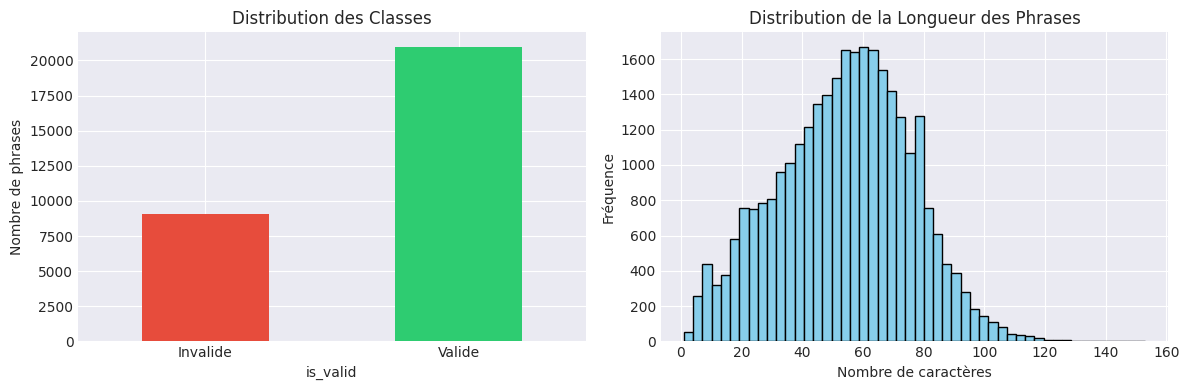


📝 Exemples de phrases valides:
   1. Je veu alé de Lamothe-Montravel a hoerdt svp c urgent
   2. Quel est le dernier train port de Saint-Amand-Lonngpré port de Joué-lès-Tours ?
   3. Donne-moi les horaires Lyon Saint-Pal PONTHHIÉRY - Priingy

📝 Exemples de phrases invalides:
   1. Je vais à l'université 🚉
   2. Le TGV est COPLETT
   3. Je vais de Rivage-Imaginaire à Villefictive


In [4]:
# Statistiques de base
print("📈 Statistiques du dataset:")
print(f"   Total de phrases: {len(df)}")
print(f"   Phrases valides (is_valid=1): {df['is_valid'].sum()} ({df['is_valid'].mean()*100:.1f}%)")
print(f"   Phrases invalides (is_valid=0): {(df['is_valid']==0).sum()} ({(df['is_valid']==0).mean()*100:.1f}%)")

# Longueur des phrases
df['sentence_length'] = df['sentence'].str.len()
print(f"\n📏 Longueur des phrases:")
print(f"   Moyenne: {df['sentence_length'].mean():.1f} caractères")
print(f"   Médiane: {df['sentence_length'].median():.1f} caractères")
print(f"   Min: {df['sentence_length'].min()} caractères")
print(f"   Max: {df['sentence_length'].max()} caractères")

# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution des classes
# Trier par index pour garantir l'ordre [0, 1] (Invalide, Valide)
# value_counts() trie par défaut par fréquence décroissante, donc on trie par index
class_counts = df['is_valid'].value_counts().sort_index()
class_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribution des Classes')
axes[0].set_xlabel('is_valid')
axes[0].set_ylabel('Nombre de phrases')
axes[0].set_xticklabels(['Invalide', 'Valide'], rotation=0)

# Distribution de la longueur des phrases
df['sentence_length'].hist(bins=50, ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('Distribution de la Longueur des Phrases')
axes[1].set_xlabel('Nombre de caractères')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

# Exemples de phrases
print("\n📝 Exemples de phrases valides:")
valid_examples = df[df['is_valid'] == 1]['sentence'].head(3)
for i, ex in enumerate(valid_examples, 1):
    print(f"   {i}. {ex}")

print("\n📝 Exemples de phrases invalides:")
invalid_examples = df[df['is_valid'] == 0]['sentence'].head(3)
for i, ex in enumerate(invalid_examples, 1):
    print(f"   {i}. {ex}")


## 3. Preprocessing

**Objectif** : Préparer les données pour l'entraînement en les divisant en ensembles et en les transformant en format numérique.

**Ce qu'on fait** :
1. **Séparation des features et labels** : Extraire les phrases (X) et les labels is_valid (y)
2. **Division train/validation/test** : Séparer les données en 3 ensembles :
   - **Train** (70%) : Pour entraîner le modèle
   - **Validation** (10%) : Pour ajuster les hyperparamètres et évaluer pendant l'entraînement
   - **Test** (20%) : Pour évaluer les performances finales (jamais utilisé pendant l'entraînement)
3. **Stratification** : Maintenir la même proportion de classes valides/invalides dans chaque ensemble

**Pourquoi** : 
- Le split permet d'évaluer si le modèle généralise bien (ne mémorise pas juste les données d'entraînement)
- La stratification garantit que chaque ensemble a la même distribution de classes, ce qui est important pour un entraînement équilibré


In [5]:
# Préparation des données
X = df['sentence'].values
y = df['is_valid'].values

print(f"📊 Données préparées:")
print(f"   X (phrases): {len(X)}")
print(f"   y (labels): {len(y)}")
print(f"   Distribution de y: {np.bincount(y)}")

# Split train/test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y if STRATIFY else None
)

# Split train/validation
val_size_adjusted = VAL_SIZE / (1 - TEST_SIZE)  # Ajuster pour le split en deux étapes
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_size_adjusted,
    random_state=RANDOM_SEED,
    stratify=y_temp if STRATIFY else None
)

print(f"\n📦 Split des données:")
print(f"   Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\n   Distribution train: {np.bincount(y_train)}")
print(f"   Distribution validation: {np.bincount(y_val)}")
print(f"   Distribution test: {np.bincount(y_test)}")


📊 Données préparées:
   X (phrases): 30000
   y (labels): 30000
   Distribution de y: [ 9043 20957]

📦 Split des données:
   Train: 21000 (70.0%)
   Validation: 3000 (10.0%)
   Test: 6000 (20.0%)

   Distribution train: [ 6330 14670]
   Distribution validation: [ 904 2096]
   Distribution test: [1809 4191]


### Vectorisation TF-IDF

**Objectif** : Transformer les phrases (texte) en vecteurs numériques que les algorithmes de machine learning peuvent comprendre.

**Ce qu'on fait** :
1. **Créer un vectorizer TF-IDF** avec les paramètres configurés :
   - `min_df=2` : Ignore les mots qui apparaissent dans moins de 2 documents (mots trop rares)
   - `max_df=0.95` : Ignore les mots qui apparaissent dans plus de 95% des documents (mots trop communs comme "le", "de")
   - `max_features=10000` : Limite à 10000 mots les plus importants (pour réduire la taille)
   - `ngram_range=(1,2)` : Prend en compte les mots individuels ET les paires de mots consécutifs (ex: "train de" est une feature)
   - `lowercase=False` : Garde la casse originale (important pour préserver les variations)

2. **Fit sur le train** : Apprendre le vocabulaire uniquement sur les données d'entraînement
3. **Transform** : Appliquer cette transformation sur train, validation et test

**TF-IDF expliqué simplement** :
- **TF (Term Frequency)** : Fréquence d'un mot dans un document (phrase)
- **IDF (Inverse Document Frequency)** : Rareté du mot dans tout le corpus
- Un mot a un score élevé s'il est fréquent dans une phrase MAIS rare dans l'ensemble du corpus (donc caractéristique de cette phrase)

**Pourquoi** : Les modèles de machine learning ne comprennent que les nombres, pas le texte. TF-IDF convertit chaque phrase en un vecteur de nombres où chaque dimension représente l'importance d'un mot/ngramme.

**⚠️ Important** : On fait le `fit` uniquement sur le train pour éviter le "data leakage" (fuite d'information). Si on fit sur tout le dataset, le modèle verrait des informations du test pendant l'entraînement.


In [6]:
# Création du vectorizer TF-IDF
vectorizer = TfidfVectorizer(
    lowercase=LOWERCASE,
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    analyzer='word'
)

print("🔄 Vectorisation TF-IDF...")
print(f"   Paramètres: min_df={MIN_DF}, max_df={MAX_DF}, max_features={MAX_FEATURES}")
print(f"   ngram_range={NGRAM_RANGE}, lowercase={LOWERCASE}")

# Fit sur le train et transform sur tous les sets
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print(f"✅ Vectorisation terminée")
print(f"   Train shape: {X_train_tfidf.shape}")
print(f"   Validation shape: {X_val_tfidf.shape}")
print(f"   Test shape: {X_test_tfidf.shape}")
print(f"   Nombre de features: {X_train_tfidf.shape[1]}")


🔄 Vectorisation TF-IDF...
   Paramètres: min_df=2, max_df=0.95, max_features=10000
   ngram_range=(1, 2), lowercase=False
✅ Vectorisation terminée
   Train shape: (21000, 10000)
   Validation shape: (3000, 10000)
   Test shape: (6000, 10000)
   Nombre de features: 10000


## 4. Entraînement avec Checkpoints

**Objectif** : Entraîner le modèle tout en sauvegardant des versions intermédiaires pour pouvoir reprendre ou comparer.

**Ce qu'on fait** :
- Entraîner le modèle sur les données d'entraînement
- Pendant l'entraînement, sauvegarder des "checkpoints" (snapshots) du modèle à intervalles réguliers
- Chaque checkpoint contient : le modèle, le vectorizer, et les métriques de performance

**Pourquoi les checkpoints** :
- Si l'entraînement est interrompu, on peut reprendre depuis un checkpoint
- Permet de comparer différentes versions du modèle
- Permet de choisir le meilleur modèle parmi plusieurs checkpoints
- Utile pour le debugging (voir comment le modèle évolue)

### Fonction de sauvegarde de checkpoint

**Objectif** : Créer des fonctions pour sauvegarder et recharger les checkpoints facilement.

**Ce qu'on fait** :
- `save_checkpoint()` : Sauvegarde le modèle, le vectorizer et les métriques dans des fichiers
- `load_checkpoint()` : Recharge un checkpoint précédemment sauvegardé

**Structure des fichiers sauvegardés** :
- `checkpoint_XXX.joblib` : Le modèle entraîné
- `vectorizer_XXX.joblib` : Le vectorizer (nécessaire pour transformer de nouvelles phrases)
- `metrics_XXX.json` : Les métriques de performance (accuracy, F1, etc.)


In [7]:
def save_checkpoint(model, vectorizer, metrics, checkpoint_num, experiment_name):
    """Sauvegarde un checkpoint du modèle avec ses métriques."""
    checkpoint_dir = CHECKPOINTS_DIR / experiment_name
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    
    # Nom du fichier
    checkpoint_file = checkpoint_dir / f"checkpoint_{checkpoint_num:03d}.joblib"
    vectorizer_file = checkpoint_dir / f"vectorizer_{checkpoint_num:03d}.joblib"
    metrics_file = checkpoint_dir / f"metrics_{checkpoint_num:03d}.json"
    
    # Sauvegarder
    joblib.dump(model, checkpoint_file)
    joblib.dump(vectorizer, vectorizer_file)
    
    with open(metrics_file, 'w', encoding='utf-8') as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)
    
    print(f"   💾 Checkpoint {checkpoint_num} sauvegardé: {checkpoint_file}")
    return checkpoint_file

def load_checkpoint(checkpoint_num, experiment_name):
    """Charge un checkpoint."""
    checkpoint_dir = CHECKPOINTS_DIR / experiment_name
    checkpoint_file = checkpoint_dir / f"checkpoint_{checkpoint_num:03d}.joblib"
    vectorizer_file = checkpoint_dir / f"vectorizer_{checkpoint_num:03d}.joblib"
    metrics_file = checkpoint_dir / f"metrics_{checkpoint_num:03d}.json"
    
    model = joblib.load(checkpoint_file)
    vectorizer = joblib.load(vectorizer_file)
    
    with open(metrics_file, 'r', encoding='utf-8') as f:
        metrics = json.load(f)
    
    return model, vectorizer, metrics

print("✅ Fonctions de checkpoint définies")


✅ Fonctions de checkpoint définies


### Création et entraînement du modèle

**Objectif** : Créer le modèle selon le type choisi et l'entraîner sur les données.

**Ce qu'on fait** :

1. **Création du modèle** :
   - Selon `MODEL_TYPE`, on crée le bon type de modèle (Logistic Regression, SVM, etc.)
   - On applique la configuration définie dans `MODEL_CONFIGS` (hyperparamètres comme C, max_iter, etc.)

2. **Entraînement avec checkpoints** (si activé) :
   - On utilise la **cross-validation** (StratifiedKFold) pour créer plusieurs checkpoints
   - Le dataset d'entraînement est divisé en N folds (ex: 10)
   - Pour chaque fold :
     a. On entraîne le modèle sur une partie des données
     b. On évalue sur l'autre partie (validation interne)
     c. On calcule les métriques (accuracy, precision, recall, F1)
     d. On sauvegarde un checkpoint avec ces métriques
   - Après tous les folds, on entraîne le modèle final sur TOUT le dataset d'entraînement
   - On évalue ce modèle final sur le set de validation
   - On sauvegarde le checkpoint final

3. **Entraînement simple** (si checkpoints désactivés) :
   - On entraîne directement sur tout le dataset d'entraînement

**Cross-validation expliquée** :
- Divise les données en N parties (folds)
- Pour chaque fold, utilise N-1 parties pour entraîner et 1 partie pour valider
- Permet d'avoir une estimation plus robuste de la performance
- Ici, on l'utilise aussi pour créer des checkpoints à différents stades

**Pourquoi** : 
- La cross-validation permet d'avoir plusieurs évaluations du modèle sur différentes parties des données
- Les checkpoints permettent de garder une trace de l'évolution du modèle
- L'entraînement final sur tout le train maximise l'utilisation des données disponibles


In [8]:
# Fonction utilitaire pour créer un modèle selon le type
def create_model(model_type, config):
    """Crée un modèle selon le type spécifié."""
    if model_type == "logistic_regression":
        return LogisticRegression(**config)
    elif model_type == "svm":
        return SVC(**config, probability=True)  # probability=True pour avoir predict_proba
    elif model_type == "random_forest":
        return RandomForestClassifier(**config)
    elif model_type == "gradient_boosting":
        return GradientBoostingClassifier(**config)
    else:
        raise ValueError(f"Type de modèle inconnu: {model_type}")

print("✅ Fonction create_model() définie")
print(f"📋 Modèles à entraîner: {MODELS_TO_TRAIN}")



✅ Fonction create_model() définie
📋 Modèles à entraîner: ['logistic_regression', 'svm', 'random_forest', 'gradient_boosting']


### Entraînement de tous les modèles avec suivi détaillé

**Objectif** : Entraîner tous les modèles configurés avec un suivi détaillé des métriques et visualisation de la progression.

**Approche d'entraînement progressif** :
- **Subset croissant des données** : Chaque epoch utilise plus de données d'entraînement
  - Epoch 1 : 10% des données
  - Epoch 2 : 20% des données
  - ...
  - Epoch 10 : 100% des données
- Cela permet de voir une **vraie progression** : le modèle s'améliore avec plus de données
- Chaque epoch entraîne un nouveau modèle sur un subset plus grand

**Modèles entraînés** :
- Logistic Regression
- SVM (Support Vector Machine)
- Random Forest
- Gradient Boosting

**Améliorations** :
- Affichage détaillé de toutes les métriques (Accuracy, Precision, Recall, F1, AUC) à chaque epoch
- Suivi du temps d'entraînement et du pourcentage de données utilisées
- Détection du meilleur modèle (early stopping optionnel)
- Visualisation de la progression avec graphiques
- Comparaison train vs validation pour détecter l'overfitting
- Sauvegarde des résultats de tous les modèles pour comparaison


In [9]:
# ============================================================================
# ENTRAÎNEMENT DE TOUS LES MODÈLES AVEC SUIVI DÉTAILLÉ
# ============================================================================

from time import time
import numpy as np

# Dictionnaire pour stocker les résultats de tous les modèles
all_models_results = {}

print(f"\n🚀 Démarrage de l'entraînement de {len(MODELS_TO_TRAIN)} modèle(s)...")
print(f"   Modèles: {', '.join(MODELS_TO_TRAIN)}")
print(f"   Train size: {X_train_tfidf.shape[0]}, Val size: {X_val_tfidf.shape[0]}")
print(f"=" * 80)

# Boucle sur tous les modèles à entraîner
for model_idx, MODEL_TYPE in enumerate(MODELS_TO_TRAIN, 1):
    print(f"\n{'='*80}")
    print(f"🤖 MODÈLE {model_idx}/{len(MODELS_TO_TRAIN)}: {MODEL_TYPE.upper()}")
    print(f"{'='*80}")
    
    # Créer le modèle
    model_config = MODEL_CONFIGS[MODEL_TYPE]
    model = create_model(MODEL_TYPE, model_config)
    
    print(f"   Configuration: {model_config}")
    
    # Historique pour visualisation
    training_history = {
        'epoch': [],
        'train_acc': [],
        'val_acc': [],
        'val_prec': [],
        'val_rec': [],
        'val_f1': [],
        'val_auc': [],
        'time': []
    }

    best_f1 = 0.0
    best_epoch = 0
    patience_counter = 0
    start_time = time()

    if SAVE_CHECKPOINTS:
        n_checkpoints = int(1 / CHECKPOINT_INTERVAL)  # Nombre de checkpoints
        checkpoint_num = 0
    
        # Sauvegarder checkpoint initial
        initial_metrics = {
        'epoch': 0,
        'accuracy': 0.0,
        'precision': 0.0,
        'recall': 0.0,
        'f1_score': 0.0,
        'timestamp': datetime.now().isoformat()
        }
        save_checkpoint(model, vectorizer, initial_metrics, checkpoint_num, EXPERIMENT_NAME)
        checkpoint_num += 1
    
        # Approche d'entraînement progressif : utiliser un subset croissant des données
        # Cela permet de voir une vraie progression au lieu de juste réentraîner le même modèle
        train_size = X_train_tfidf.shape[0]
        indices = np.array([], dtype=int)  # Initialiser les indices
    
        # Entraînement progressif avec subset croissant des données
        for epoch in range(1, n_checkpoints + 1):
            epoch_start = time()
        
            # Calculer la proportion de données à utiliser pour cet epoch
            # Epoch 1 = 10% des données, Epoch 2 = 20%, ..., Epoch 10 = 100%
            data_proportion = epoch / n_checkpoints
            n_samples = int(train_size * data_proportion)
        
        # Sélectionner un subset progressif des données d'entraînement
        if epoch == 1:
            # Premier epoch : utiliser un petit subset
            indices = np.random.choice(train_size, size=n_samples, replace=False)
            indices = np.sort(indices)  # Trier pour maintenir l'ordre
        else:
            # Pour les epochs suivants, on ajoute progressivement des données
            # On garde les indices précédents et on en ajoute de nouveaux
            prev_n_samples = len(indices)
            new_samples = n_samples - prev_n_samples
            # Prendre de nouveaux échantillons parmi ceux non encore utilisés
            remaining_indices = np.setdiff1d(np.arange(train_size), indices)
            if len(remaining_indices) > 0 and new_samples > 0:
                new_indices = np.random.choice(remaining_indices, size=min(new_samples, len(remaining_indices)), replace=False)
                indices = np.concatenate([indices, new_indices])
                indices = np.sort(indices)
            else:
                indices = np.arange(train_size)  # Utiliser toutes les données
        
            # Sélectionner les données pour cet epoch
            X_epoch_train = X_train_tfidf[indices]
            y_epoch_train = y_train[indices]
        
            # Créer un nouveau modèle pour cet epoch
            model = create_model(MODEL_TYPE, model_config)
        
            # Entraîner sur le subset
            model.fit(X_epoch_train, y_epoch_train)
        
            # Évaluer sur le subset d'entraînement utilisé (pour voir la progression)
            y_epoch_train_pred = model.predict(X_epoch_train)
            train_acc = accuracy_score(y_epoch_train, y_epoch_train_pred)
        
            # Évaluer sur validation
            y_val_pred = model.predict(X_val_tfidf)
            y_val_proba = model.predict_proba(X_val_tfidf)[:, 1] if hasattr(model, 'predict_proba') else None
        
            val_acc = accuracy_score(y_val, y_val_pred)
            val_prec = precision_score(y_val, y_val_pred, zero_division=0)
            val_rec = recall_score(y_val, y_val_pred, zero_division=0)
            val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
            val_auc = roc_auc_score(y_val, y_val_proba) if y_val_proba is not None else 0.0
        
            epoch_time = time() - epoch_start
            total_time = time() - start_time
        
            # Enregistrer dans l'historique
            training_history['epoch'].append(epoch)
            training_history['train_acc'].append(train_acc)
            training_history['val_acc'].append(val_acc)
            training_history['val_prec'].append(val_prec)
            training_history['val_rec'].append(val_rec)
            training_history['val_f1'].append(val_f1)
            training_history['val_auc'].append(val_auc)
            training_history['time'].append(total_time)
        
            # Afficher les détails avec plus d'informations
            data_pct = (n_samples / train_size) * 100
            print(f"\n📊 [{MODEL_TYPE.upper()}] Epoch {epoch}/{n_checkpoints} (données: {n_samples}/{train_size} = {data_pct:.1f}%, temps: {epoch_time:.1f}s, total: {total_time:.1f}s)")
            print(f"   📈 Train - Acc: {train_acc:.4f}")
            print(f"   📊 Val   - Acc: {val_acc:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | F1: {val_f1:.4f} | AUC: {val_auc:.4f}")
            
            # Afficher la progression par rapport à l'epoch précédent
            if epoch > 1:
                prev_f1 = training_history['val_f1'][-2] if len(training_history['val_f1']) > 1 else 0
                f1_diff = val_f1 - prev_f1
                if f1_diff > 0:
                    print(f"   📈 Progression F1: +{f1_diff:.4f} (amélioration)")
                elif f1_diff < 0:
                    print(f"   📉 Progression F1: {f1_diff:.4f} (dégradation)")
                else:
                    print(f"   ➡️  Progression F1: {f1_diff:.4f} (stable)")
        
                                    # Early stopping
            if val_f1 > best_f1:
                best_f1 = val_f1
                best_epoch = epoch
                patience_counter = 0
                improvement = val_f1 - (training_history['val_f1'][-2] if len(training_history['val_f1']) > 1 else 0)
                print(f"   ✨ Meilleur F1: {best_f1:.4f} (epoch {best_epoch}) | Amélioration: +{improvement:.4f}")
            else:
                patience_counter += 1
                if EARLY_STOPPING and patience_counter >= EARLY_STOPPING_PATIENCE:
                    print(f"   ⏹️  Early stopping après {patience_counter} epochs sans amélioration")
                    print(f"   💡 Meilleur modèle était à l'epoch {best_epoch} avec F1={best_f1:.4f}")
                    break
        
            # Sauvegarder checkpoint
            checkpoint_metrics = {
            'epoch': epoch,
            'accuracy': float(val_acc),
            'precision': float(val_prec),
            'recall': float(val_rec),
            'f1_score': float(val_f1),
            'roc_auc': float(val_auc),
            'train_accuracy': float(train_acc),
            'timestamp': datetime.now().isoformat()
            }
            save_checkpoint(model, vectorizer, checkpoint_metrics, checkpoint_num, EXPERIMENT_NAME)
            checkpoint_num += 1
    
            # Entraînement final sur tout le train set
            print(f"\n🎯 Entraînement final sur tout le dataset d'entraînement...")
            if MODEL_TYPE == "logistic_regression":
                # Utiliser le max_iter original
                model = create_model(MODEL_TYPE, model_config)
            model.fit(X_train_tfidf, y_train)
            
            # Évaluer sur la validation set
            y_val_pred = model.predict(X_val_tfidf)
            y_val_proba = model.predict_proba(X_val_tfidf)[:, 1] if hasattr(model, 'predict_proba') else None
            
            val_acc = accuracy_score(y_val, y_val_pred)
            val_prec = precision_score(y_val, y_val_pred, zero_division=0)
            val_rec = recall_score(y_val, y_val_pred, zero_division=0)
            val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
            val_auc = roc_auc_score(y_val, y_val_proba) if y_val_proba is not None else 0.0
            
            total_time = time() - start_time
            print(f"\n{'='*80}")
            print(f"✅ [{MODEL_TYPE.upper()}] Entraînement terminé (temps total: {total_time:.1f}s)")
            print(f"{'='*80}")
            print(f"📊 Résultats finaux sur validation:")
            print(f"   Accuracy:  {val_acc:.4f}")
            print(f"   Precision: {val_prec:.4f}")
            print(f"   Recall:    {val_rec:.4f}")
            print(f"   F1-Score:  {val_f1:.4f}")
            print(f"   ROC-AUC:   {val_auc:.4f}")
            print(f"   Meilleur F1 pendant l'entraînement: {best_f1:.4f} (epoch {best_epoch})")
            print(f"{'='*80}\n")
        
            # Sauvegarder le checkpoint final
            final_metrics = {
            'epoch': 'final',
            'accuracy': float(val_acc),
            'precision': float(val_prec),
            'recall': float(val_rec),
            'f1_score': float(val_f1),
            'roc_auc': float(val_auc),
            'best_f1': float(best_f1),
            'best_epoch': int(best_epoch),
            'timestamp': datetime.now().isoformat()
            }
            save_checkpoint(model, vectorizer, final_metrics, checkpoint_num, EXPERIMENT_NAME)
        
                                    # Stocker les résultats pour comparaison
            all_models_results[MODEL_TYPE] = {
                'model': model,
                'vectorizer': vectorizer,
                'val_acc': val_acc,
                'val_prec': val_prec,
                'val_rec': val_rec,
                'val_f1': val_f1,
                'val_auc': val_auc,
                'best_f1': best_f1,
                'best_epoch': best_epoch,
                'total_time': total_time,
                'training_history': training_history.copy()
            }
            
            # Afficher un résumé rapide pour ce modèle
            print(f"💾 Résultats de {MODEL_TYPE.upper()} sauvegardés pour comparaison")
        
            # Visualiser la progression
            if len(training_history['epoch']) > 1:
                fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
                epochs = training_history['epoch']
            
            # Accuracy
                axes[0, 0].plot(epochs, training_history['train_acc'], 'b-o', label='Train', linewidth=2, markersize=6)
                axes[0, 0].plot(epochs, training_history['val_acc'], 'r-o', label='Validation', linewidth=2, markersize=6)
                axes[0, 0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5, label=f'Meilleur (epoch {best_epoch})')
                axes[0, 0].set_xlabel('Epoch')
                axes[0, 0].set_ylabel('Accuracy')
                axes[0, 0].set_title('Évolution de l\'Accuracy')
                axes[0, 0].legend()
                axes[0, 0].grid(True, alpha=0.3)
            
            # F1 Score
                axes[0, 1].plot(epochs, training_history['val_f1'], 'g-o', label='Validation F1', linewidth=2, markersize=6)
                axes[0, 1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5, label=f'Meilleur (epoch {best_epoch})')
                axes[0, 1].set_xlabel('Epoch')
                axes[0, 1].set_ylabel('F1 Score')
                axes[0, 1].set_title('Évolution du F1 Score')
                axes[0, 1].legend()
                axes[0, 1].grid(True, alpha=0.3)
            
            # Precision & Recall
                axes[1, 0].plot(epochs, training_history['val_prec'], 'b-o', label='Precision', linewidth=2, markersize=6)
                axes[1, 0].plot(epochs, training_history['val_rec'], 'r-o', label='Recall', linewidth=2, markersize=6)
                axes[1, 0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5)
                axes[1, 0].set_xlabel('Epoch')
                axes[1, 0].set_ylabel('Score')
                axes[1, 0].set_title('Évolution Precision & Recall')
                axes[1, 0].legend()
                axes[1, 0].grid(True, alpha=0.3)
            
            # ROC-AUC
                axes[1, 1].plot(epochs, training_history['val_auc'], 'm-o', label='ROC-AUC', linewidth=2, markersize=6)
                axes[1, 1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5)
                axes[1, 1].set_xlabel('Epoch')
                axes[1, 1].set_ylabel('ROC-AUC')
                axes[1, 1].set_title('Évolution du ROC-AUC')
                axes[1, 1].legend()
                axes[1, 1].grid(True, alpha=0.3)
            
                plt.tight_layout()
                plt.show()
            
                print(f"\n📈 Résumé de la progression:")
                print(f"   Meilleur F1: {best_f1:.4f} à l'epoch {best_epoch}")
                print(f"   F1 final: {val_f1:.4f}")
            if val_f1 < best_f1:
                print(f"   ⚠️  Le modèle final est moins bon que le meilleur checkpoint (différence: {best_f1 - val_f1:.4f})")
                print(f"   💡 Considérez utiliser le checkpoint de l'epoch {best_epoch}")

    else:
        # Entraînement simple sans checkpoints
        # Créer le modèle si ce n'est pas déjà fait
        if 'model' not in locals() or model is None:
            model = create_model(MODEL_TYPE, model_config)
        
        start_time = time()
        model.fit(X_train_tfidf, y_train)
        training_time = time() - start_time
        
        # Évaluer sur la validation set
        y_val_pred = model.predict(X_val_tfidf)
        y_val_proba = model.predict_proba(X_val_tfidf)[:, 1] if hasattr(model, 'predict_proba') else None
        
        val_acc = accuracy_score(y_val, y_val_pred)
        val_prec = precision_score(y_val, y_val_pred, zero_division=0)
        val_rec = recall_score(y_val, y_val_pred, zero_division=0)
        val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
        val_auc = roc_auc_score(y_val, y_val_proba) if y_val_proba is not None else 0.0
        
        print(f"\n{'='*80}")
        print(f"✅ [{MODEL_TYPE.upper()}] Entraînement terminé (temps: {training_time:.1f}s)")
        print(f"{'='*80}")
        print(f"📊 Résultats finaux sur validation:")
        print(f"   Accuracy:  {val_acc:.4f}")
        print(f"   Precision: {val_prec:.4f}")
        print(f"   Recall:    {val_rec:.4f}")
        print(f"   F1-Score:  {val_f1:.4f}")
        print(f"   ROC-AUC:   {val_auc:.4f}")
        print(f"{'='*80}\n")
        
        # Stocker les résultats pour comparaison
        all_models_results[MODEL_TYPE] = {
            'model': model,
            'vectorizer': vectorizer,
            'val_acc': val_acc,
            'val_prec': val_prec,
            'val_rec': val_rec,
            'val_f1': val_f1,
            'val_auc': val_auc,
            'total_time': training_time
        }
        
        # Afficher un résumé rapide pour ce modèle
        print(f"💾 Résultats de {MODEL_TYPE.upper()} sauvegardés pour comparaison")

# Résumé final de tous les modèles entraînés
print(f"\n{'='*80}")
print(f"✅ TOUS LES MODÈLES ONT ÉTÉ ENTRÂINÉS")
print(f"{'='*80}")

if len(all_models_results) > 0:
    print(f"\n📊 RÉSUMÉ DES RÉSULTATS PAR MODÈLE:")
    print(f"{'='*80}")
    print(f"{'Modèle':<25} | {'F1':<8} | {'Acc':<8} | {'Prec':<8} | {'Rec':<8} | {'AUC':<8} | {'Temps':<10}")
    print(f"{'-'*80}")

    for model_name, results in all_models_results.items():
        model_display = model_name.replace('_', ' ').title()
        print(f"{model_display:<25} | {results['val_f1']:.4f} | {results['val_acc']:.4f} | {results['val_prec']:.4f} | {results['val_rec']:.4f} | {results.get('val_auc', 0.0):.4f} | {results['total_time']:>8.1f}s")

    print(f"{'='*80}")

    # Identifier le meilleur modèle
    best_model = max(all_models_results.items(), key=lambda x: x[1]['val_f1'])
    print(f"\n🏆 MEILLEUR MODÈLE: {best_model[0].replace('_', ' ').title()}")
    print(f"   F1-Score: {best_model[1]['val_f1']:.4f}")
    print(f"   Accuracy: {best_model[1]['val_acc']:.4f}")
    print(f"   Temps d'entraînement: {best_model[1]['total_time']:.1f}s")
else:
    print("⚠️  Aucun modèle n'a été entraîné. Vérifiez MODELS_TO_TRAIN dans la configuration.")



🚀 Démarrage de l'entraînement de 4 modèle(s)...
   Modèles: logistic_regression, svm, random_forest, gradient_boosting
   Train size: 21000, Val size: 3000

🤖 MODÈLE 1/4: LOGISTIC_REGRESSION
   Configuration: {'C': 1.0, 'max_iter': 1000, 'solver': 'lbfgs', 'class_weight': 'balanced'}
   💾 Checkpoint 0 sauvegardé: /workspace/classifier/checkpoints/validity_classifier_20260106_205631/checkpoint_000.joblib

📊 [LOGISTIC_REGRESSION] Epoch 10/10 (données: 21000/21000 = 100.0%, temps: 0.1s, total: 0.2s)
   📈 Train - Acc: 0.9559
   📊 Val   - Acc: 0.9330 | Prec: 0.9716 | Rec: 0.9313 | F1: 0.9510 | AUC: 0.9846
   📈 Progression F1: +0.9510 (amélioration)
   ✨ Meilleur F1: 0.9510 (epoch 10) | Amélioration: +0.9510
   💾 Checkpoint 1 sauvegardé: /workspace/classifier/checkpoints/validity_classifier_20260106_205631/checkpoint_001.joblib

🎯 Entraînement final sur tout le dataset d'entraînement...

✅ [LOGISTIC_REGRESSION] Entraînement terminé (temps total: 0.3s)
📊 Résultats finaux sur validation:
   A

### Comparaison des modèles entraînés

**Objectif** : Comparer les performances de tous les modèles entraînés pour identifier le meilleur.

**Métriques comparées** :
- Accuracy (Précision globale)
- Precision (Précision des prédictions positives)
- Recall (Taux de détection des phrases valides)
- F1-Score (Moyenne harmonique de Precision et Recall)
- ROC-AUC (Aire sous la courbe ROC)
- Temps d'entraînement

---

### Suggestions pour améliorer les performances

**Si vous observez une stagnation ou une baisse de performance :**

1. **Ajuster les hyperparamètres** :
   - Pour Logistic Regression : Essayer différentes valeurs de `C` (0.1, 0.5, 1.0, 2.0, 5.0)
   - Augmenter `max_iter` si la convergence n'est pas atteinte
   - Essayer différents `solver` ('lbfgs', 'liblinear', 'sag', 'saga')

2. **Améliorer le preprocessing** :
   - Ajuster `MAX_FEATURES` (essayer 5000, 10000, 20000)
   - Modifier `NGRAM_RANGE` (essayer (1,1), (1,2), (1,3))
   - Ajuster `MIN_DF` et `MAX_DF`

3. **Essayer d'autres modèles** :
   - `MODEL_TYPE = "svm"` avec différents kernels
   - `MODEL_TYPE = "random_forest"` avec plus d'arbres
   - `MODEL_TYPE = "gradient_boosting"` avec tuning des hyperparamètres

4. **Analyser l'overfitting** :
   - Si `train_acc` >> `val_acc` : le modèle overfit
   - Solution : Réduire la complexité, ajouter de la régularisation, augmenter le dataset

5. **Utiliser le meilleur checkpoint** :
   - Si le modèle final est moins bon que le meilleur checkpoint, chargez le checkpoint de l'epoch avec le meilleur F1


📊 COMPARAISON DES MODÈLES
             Modèle  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Temps (s)
Logistic Regression  0.933000   0.971628 0.931298  0.951035 0.984550   0.317478
                Svm  0.933000   0.971628 0.931298  0.951035 0.982422  82.664822
  Gradient Boosting  0.906333   0.914952 0.954676  0.934392 0.967630  15.266892
      Random Forest  0.833333   0.948819 0.804866  0.870934 0.944805   1.419068

🏆 MEILLEUR MODÈLE: Logistic Regression
   F1-Score: 0.9510


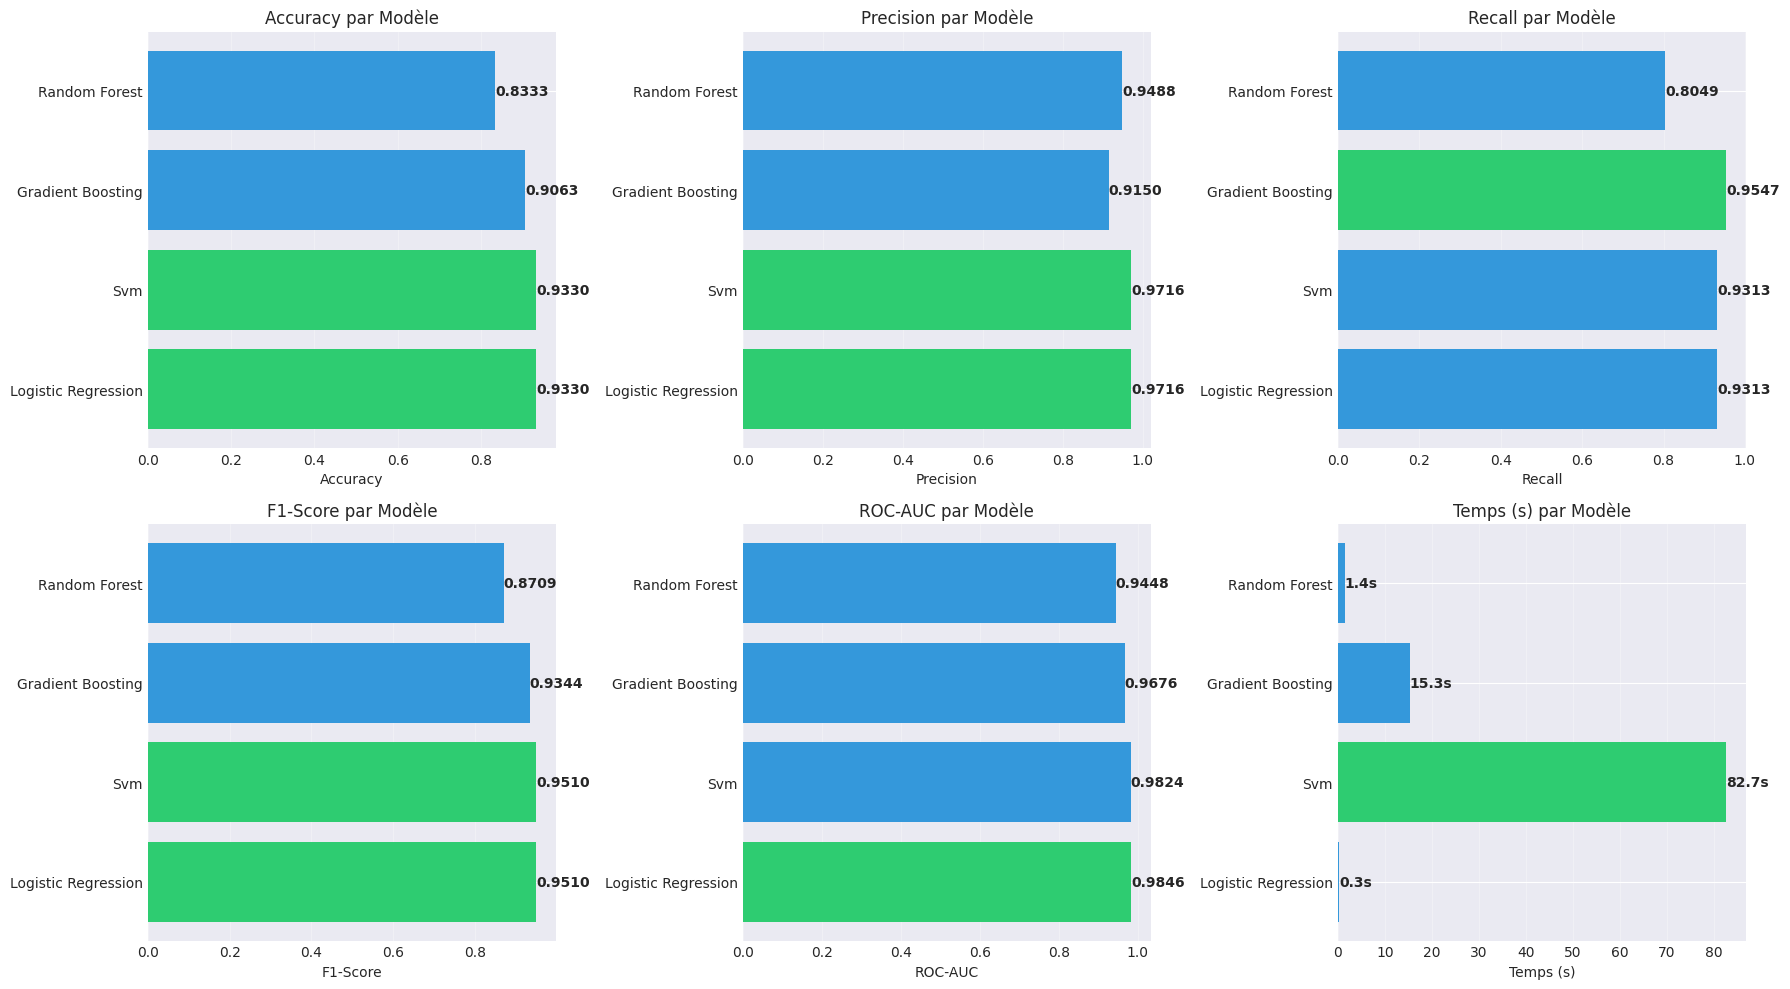


💾 Comparaison sauvegardée: /workspace/classifier/results/validity_classifier_20260106_205631/models_comparison.csv

✅ Modèle sélectionné pour les sections suivantes: logistic_regression
   F1-Score: 0.9510
   ROC-AUC: 0.9846
   Accuracy: 0.9330


In [10]:
# ============================================================================
# COMPARAISON DES MODÈLES
# ============================================================================

if len(all_models_results) > 0:
    # Créer un DataFrame pour la comparaison
    comparison_data = []
    for model_name, results in all_models_results.items():
        comparison_data.append({
            'Modèle': model_name.replace('_', ' ').title(),
            'Accuracy': results['val_acc'],
            'Precision': results['val_prec'],
            'Recall': results['val_rec'],
            'F1-Score': results['val_f1'],
            'ROC-AUC': results.get('val_auc', 0.0),
            'Temps (s)': results['total_time']
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('F1-Score', ascending=False)
    
    print("📊 COMPARAISON DES MODÈLES")
    print("=" * 80)
    print(comparison_df.to_string(index=False))
    print("=" * 80)
    
    # Identifier le meilleur modèle
    best_model_name = comparison_df.iloc[0]['Modèle']
    best_f1 = comparison_df.iloc[0]['F1-Score']
    print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
    print(f"   F1-Score: {best_f1:.4f}")
    
    # Visualisation comparative
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    models = comparison_df['Modèle'].values
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Temps (s)']
    
    for idx, metric in enumerate(metrics):
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]
        
        values = comparison_df[metric].values
        colors = ['#2ecc71' if v == max(values) else '#3498db' for v in values]
        
        bars = ax.barh(models, values, color=colors)
        ax.set_xlabel(metric)
        ax.set_title(f'{metric} par Modèle')
        ax.grid(True, alpha=0.3, axis='x')
        
        # Ajouter les valeurs sur les barres
        for bar, val in zip(bars, values):
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height()/2, 
                   f'{val:.4f}' if metric != 'Temps (s)' else f'{val:.1f}s',
                   ha='left', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Sauvegarder la comparaison
    # S'assurer que RESULTS_DIR existe d'abord
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    
    # Créer le répertoire de l'expérience
    results_dir = RESULTS_DIR / EXPERIMENT_NAME
    results_dir.mkdir(parents=True, exist_ok=True)
    
    # Vérifier que le répertoire existe bien
    if not results_dir.exists():
        raise OSError(f"Impossible de créer le répertoire: {results_dir}")
    
    comparison_file = results_dir / 'models_comparison.csv'
    comparison_df.to_csv(comparison_file, index=False, encoding='utf-8')
    print(f"\n💾 Comparaison sauvegardée: {comparison_file}")
    
    # Identifier le meilleur modèle en utilisant les clés originales de all_models_results
    # Le meilleur modèle est celui avec le meilleur F1-Score (déjà trié)
    best_model_display_name = comparison_df.iloc[0]['Modèle']
    
    # Trouver la clé correspondante dans all_models_results
    best_model_key = None
    for key in all_models_results.keys():
        if key.replace('_', ' ').title() == best_model_display_name:
            best_model_key = key
            break
    
    # Si on ne trouve pas, utiliser la première clé
    if best_model_key is None:
        best_model_key = list(all_models_results.keys())[0]
        print(f"⚠️  Clé non trouvée, utilisation de la première clé: {best_model_key}")
    
    # Stocker le meilleur modèle globalement pour les sections suivantes
    model = all_models_results[best_model_key]['model']
    vectorizer = all_models_results[best_model_key]['vectorizer']
    MODEL_TYPE = best_model_key  # Mettre à jour MODEL_TYPE pour la sauvegarde
    
    print(f"\n✅ Modèle sélectionné pour les sections suivantes: {best_model_key}")
    print(f"   F1-Score: {all_models_results[best_model_key]['val_f1']:.4f}")
    print(f"   ROC-AUC: {all_models_results[best_model_key].get('val_auc', 0.0):.4f}")
    print(f"   Accuracy: {all_models_results[best_model_key]['val_acc']:.4f}")
else:
    print("⚠️  Aucun modèle n'a été entraîné. Vérifiez MODELS_TO_TRAIN dans la configuration.")


In [11]:
# Prédictions sur le test set
print("📊 Évaluation sur le test set...")
y_test_pred = model.predict(X_test_tfidf)
y_test_proba = model.predict_proba(X_test_tfidf)[:, 1] if hasattr(model, 'predict_proba') else None

# Métriques
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, zero_division=0)
test_rec = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print(f"\n✅ Métriques sur le test set:")
print(f"   Accuracy:  {test_acc:.4f}")
print(f"   Precision: {test_prec:.4f}")
print(f"   Recall:   {test_rec:.4f}")
print(f"   F1-Score: {test_f1:.4f}")

if y_test_proba is not None:
    test_auc = roc_auc_score(y_test, y_test_proba)
    print(f"   ROC-AUC:  {test_auc:.4f}")

# Rapport de classification détaillé
print(f"\n📋 Rapport de classification:")
print(classification_report(y_test, y_test_pred, target_names=['Invalide', 'Valide']))


📊 Évaluation sur le test set...

✅ Métriques sur le test set:
   Accuracy:  0.9365
   Precision: 0.9690
   Recall:   0.9392
   F1-Score: 0.9538
   ROC-AUC:  0.9819

📋 Rapport de classification:
              precision    recall  f1-score   support

    Invalide       0.87      0.93      0.90      1809
      Valide       0.97      0.94      0.95      4191

    accuracy                           0.94      6000
   macro avg       0.92      0.93      0.93      6000
weighted avg       0.94      0.94      0.94      6000



### Matrice de confusion

**Objectif** : Visualiser en détail les types d'erreurs que fait le modèle.

**Ce qu'on fait** :
- Créer une matrice 2x2 montrant :
  - **Vrais négatifs** (en haut à gauche) : Phrases invalides correctement prédites comme invalides
  - **Faux positifs** (en haut à droite) : Phrases invalides incorrectement prédites comme valides
  - **Faux négatifs** (en bas à gauche) : Phrases valides incorrectement prédites comme invalides
  - **Vrais positifs** (en bas à droite) : Phrases valides correctement prédites comme valides

- Afficher cette matrice sous forme de heatmap (carte de chaleur) avec des couleurs

**Pourquoi** :
- Permet de voir visuellement où le modèle se trompe
- Les faux positifs et faux négatifs ont des impacts différents :
  - **Faux positifs** : On traite une phrase invalide comme valide (perte de temps mais pas grave)
  - **Faux négatifs** : On ignore une phrase valide (plus grave, on rate une vraie demande)
- Aide à décider si on doit ajuster le seuil de décision ou réentraîner le modèle


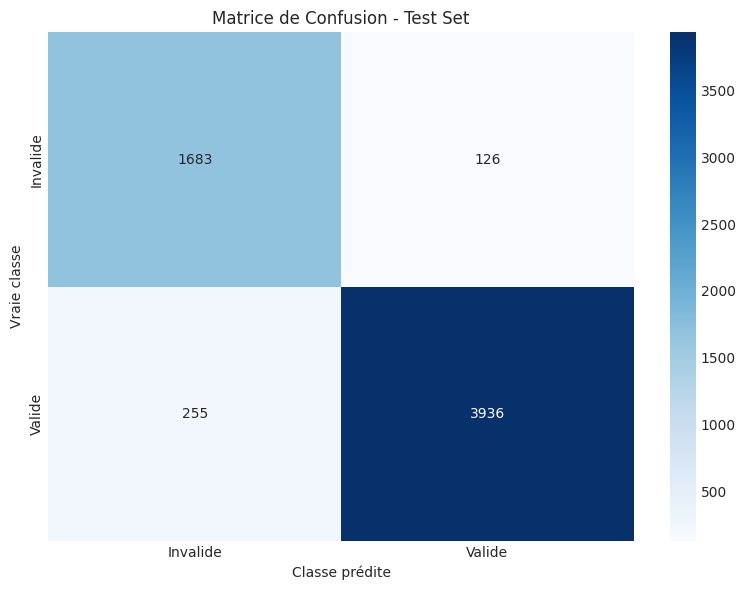

💾 Matrice de confusion sauvegardée dans /workspace/classifier/results/validity_classifier_20260106_205631


In [12]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Invalide', 'Valide'],
            yticklabels=['Invalide', 'Valide'])
plt.title('Matrice de Confusion - Test Set')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.tight_layout()

# Sauvegarder
results_dir = RESULTS_DIR / EXPERIMENT_NAME
results_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(results_dir / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"💾 Matrice de confusion sauvegardée dans {results_dir}")


### Courbes ROC et Precision-Recall

**Objectif** : Visualiser la qualité des prédictions probabilistes du modèle.

**Ce qu'on fait** :
1. **Courbe ROC (Receiver Operating Characteristic)** :
   - Axe X : Taux de faux positifs (FPR)
   - Axe Y : Taux de vrais positifs (TPR / Recall)
   - Montre la capacité du modèle à distinguer les classes à différents seuils
   - **AUC (Area Under Curve)** : Surface sous la courbe (plus proche de 1 = meilleur)
   - Une courbe au-dessus de la diagonale = meilleur que le hasard

2. **Courbe Precision-Recall** :
   - Axe X : Recall (taux de détection des phrases valides)
   - Axe Y : Precision (qualité des prédictions positives)
   - Montre le compromis entre détecter beaucoup de phrases valides vs être précis
   - Utile quand les classes sont déséquilibrées

**Pourquoi** :
- Permet de choisir le meilleur seuil de décision (actuellement 0.5 par défaut)
- Si AUC est proche de 1, le modèle sépare bien les classes
- Les courbes aident à comprendre les forces/faiblesses du modèle
- Utile pour comparer différents modèles


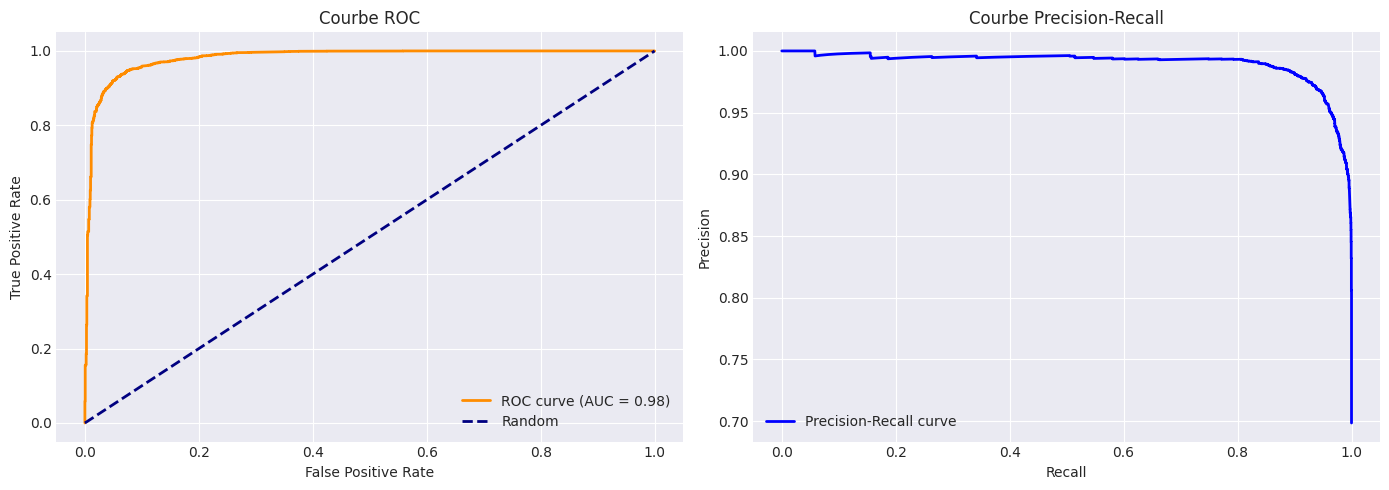

💾 Courbes sauvegardées dans /workspace/classifier/results/validity_classifier_20260106_205631


In [13]:
if y_test_proba is not None:
    # Courbe ROC
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    roc_auc = roc_auc_score(y_test, y_test_proba)
    
    # Courbe Precision-Recall
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_test_proba)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ROC
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('Courbe ROC')
    axes[0].legend(loc="lower right")
    axes[0].grid(True)
    
    # Precision-Recall
    axes[1].plot(rec_curve, prec_curve, color='blue', lw=2, label='Precision-Recall curve')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Courbe Precision-Recall')
    axes[1].legend(loc="lower left")
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig(results_dir / 'roc_pr_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"💾 Courbes sauvegardées dans {results_dir}")


### Analyse des erreurs

**Objectif** : Comprendre concrètement pourquoi et quand le modèle se trompe.

**Ce qu'on fait** :
1. **Identifier les erreurs** :
   - **Faux positifs** : Phrases vraiment invalides mais prédites comme valides
   - **Faux négatifs** : Phrases vraiment valides mais prédites comme invalides

2. **Analyser les erreurs** :
   - Afficher des exemples concrets de chaque type d'erreur
   - Montrer la probabilité de confiance du modèle pour chaque erreur
   - Sauvegarder toutes les erreurs dans un fichier CSV pour analyse approfondie

3. **Insights** :
   - Si beaucoup de faux positifs : le modèle est trop permissif
   - Si beaucoup de faux négatifs : le modèle est trop strict
   - Les probabilités proches de 0.5 indiquent des cas ambigus

**Pourquoi** :
- Comprendre les erreurs aide à améliorer le modèle
- Peut révéler des patterns dans les erreurs (ex: le modèle confond certains types de phrases)
- Permet de décider si on a besoin de plus de données d'entraînement pour certains cas
- Utile pour créer un dataset d'erreurs pour réentraîner le modèle (active learning)


In [14]:
# Analyser les erreurs
errors_df = pd.DataFrame({
    'sentence': X_test,
    'true_label': y_test,
    'predicted_label': y_test_pred,
    'probability': y_test_proba if y_test_proba is not None else [None] * len(X_test)
})

# Faux positifs (prédit valide mais invalide)
false_positives = errors_df[(errors_df['true_label'] == 0) & (errors_df['predicted_label'] == 1)]
# Faux négatifs (prédit invalide mais valide)
false_negatives = errors_df[(errors_df['true_label'] == 1) & (errors_df['predicted_label'] == 0)]

print(f"🔍 Analyse des erreurs:")
print(f"   Faux positifs (prédit valide mais invalide): {len(false_positives)}")
print(f"   Faux négatifs (prédit invalide mais valide): {len(false_negatives)}")

if len(false_positives) > 0:
    print(f"\n❌ Exemples de faux positifs (les {min(5, len(false_positives))} premiers):")
    for i, row in false_positives.head(5).iterrows():
        prob = row['probability'] if row['probability'] is not None else 'N/A'
        print(f"   [{prob:.3f}] {row['sentence']}")

if len(false_negatives) > 0:
    print(f"\n❌ Exemples de faux négatifs (les {min(5, len(false_negatives))} premiers):")
    for i, row in false_negatives.head(5).iterrows():
        prob = row['probability'] if row['probability'] is not None else 'N/A'
        print(f"   [{prob:.3f}] {row['sentence']}")

# Sauvegarder les erreurs
errors_df.to_csv(results_dir / 'errors_analysis.csv', index=False, encoding='utf-8')
print(f"\n💾 Analyse des erreurs sauvegardée dans {results_dir / 'errors_analysis.csv'}")


🔍 Analyse des erreurs:
   Faux positifs (prédit valide mais invalide): 126
   Faux négatifs (prédit invalide mais valide): 255

❌ Exemples de faux positifs (les 5 premiers):
   [0.602] 📍 Vaux-sur-Seine
   [0.890] Je REGARDE Netflix
   [0.516] L'ecriain raconte un traet de la gare de Montinyy-en-Ostrevent vers sént-laurent-en-randvaux
   [0.733] LE SCÉNARIO MONTRE UN TRAJET DE LA GARE DE VIREUX-MOLHAIN À L'AÉÉROPORT DE SAINT-ASTIER
   [0.610] LA ggare DE Sablé-sur-Sarthe la gare de Lucé 🚄

❌ Exemples de faux négatifs (les 5 premiers):
   [0.465] JE doiis aller à Martigné-Ferchaud depis port DE Cudéran méiggnac merci
   [0.380] Chateaubourg, -> saint-julien-dusault
   [0.433] Le cvoiturage de landrecies à Limoges Béédictins
   [0.307] Martres-Tolosane → centtre de luussac-les-châteaux → Glfe Juan vallauris
   [0.488] deuxime casse Bruges centre de CREST

💾 Analyse des erreurs sauvegardée dans /workspace/classifier/results/validity_classifier_20260106_205631/errors_analysis.csv


## 6. Sauvegarde du Modèle Final

**Objectif** : Sauvegarder le modèle entraîné avec toutes ses métadonnées pour pouvoir l'utiliser plus tard en production.

**⚠️ Note importante** : La sauvegarde automatique est désactivée par défaut (`SAVE_FINAL_MODEL = False`).
Pour sauvegarder le modèle, modifiez `SAVE_FINAL_MODEL = True` dans la configuration (Cellule 2).

**Ce qu'on fait** :
1. **Préparer les métadonnées** :
   - Nom de l'expérience, version, timestamp
   - Type de modèle et configuration utilisée
   - Paramètres de preprocessing (TF-IDF)
   - Statistiques du dataset (tailles, distributions)
   - Métriques de performance (test et validation)

2. **Sauvegarder** :
   - **Modèle** : Le modèle entraîné (`.joblib`)
   - **Vectorizer** : Le vectorizer TF-IDF (nécessaire pour transformer de nouvelles phrases)
   - **Métadonnées** : Toutes les infos dans un fichier JSON
   - **Métriques** : Résultats dans un CSV pour comparaison future

**Structure des fichiers** :
- `models/baseline/{model_type}_{experiment}_{version}.joblib` : Le modèle
- `models/baseline/vectorizer_{experiment}_{version}.joblib` : Le vectorizer
- `models/baseline/metadata_{experiment}_{version}.json` : Les métadonnées
- `results/{experiment}/metrics.csv` : Les métriques

**Pourquoi** :
- Permet de réutiliser le modèle sans le réentraîner
- Les métadonnées permettent de savoir exactement comment le modèle a été entraîné
- Facilite la comparaison entre différentes expériences
- Nécessaire pour déployer le modèle en production


In [15]:
# ============================================================================
# SAUVEGARDE DU MEILLEUR MODÈLE
# ============================================================================
# Cette cellule sauvegarde automatiquement le meilleur modèle parmi tous ceux entraînés
# Le meilleur modèle est sélectionné selon les métriques les plus importantes :
# 1. F1-Score (priorité principale) - métrique la plus importante pour un classifieur binaire
# 2. ROC-AUC (en cas d'égalité de F1) - capacité à distinguer les classes
# 3. Accuracy (en cas d'égalité de F1 et AUC) - précision globale
# ============================================================================

if len(all_models_results) == 0:
    print("⚠️  Aucun modèle n'a été entraîné. Impossible de sauvegarder.")
    print("   Vérifiez que la cellule d'entraînement (Cell 18) a été exécutée.")
else:
    # Sélectionner le meilleur modèle selon les métriques prioritaires
    # 1. F1-Score (priorité principale) - meilleure métrique pour classes déséquilibrées
    # 2. ROC-AUC (en cas d'égalité) - mesure la capacité de séparation
    # 3. Accuracy (en dernier recours) - précision globale
    
    print("🔍 Sélection du meilleur modèle selon les métriques prioritaires:")
    print("   1. F1-Score (priorité principale)")
    print("   2. ROC-AUC (en cas d'égalité de F1)")
    print("   3. Accuracy (en cas d'égalité de F1 et AUC)")
    print("=" * 80)
    
    best_model_key = None
    best_score = (-1.0, -1.0, -1.0)  # (F1, AUC, Accuracy)
    
    # Afficher les scores de tous les modèles pour comparaison
    print("\n📊 Scores de tous les modèles:")
    for model_key, results in all_models_results.items():
        f1 = results['val_f1']
        auc = results.get('val_auc', 0.0)
        acc = results['val_acc']
        score = (f1, auc, acc)
        model_display = model_key.replace('_', ' ').title()
        print(f"   {model_display:25s} | F1: {f1:.4f} | AUC: {auc:.4f} | Acc: {acc:.4f}")
        
        if score > best_score:
            best_score = score
            best_model_key = model_key
    
    if best_model_key is None:
        print("\n⚠️  Impossible de déterminer le meilleur modèle.")
    else:
        # Récupérer le meilleur modèle
        best_model = all_models_results[best_model_key]['model']
        best_vectorizer = all_models_results[best_model_key]['vectorizer']
        best_results = all_models_results[best_model_key]
        
        print(f"\n{'='*80}")
        print(f"🏆 MEILLEUR MODÈLE SÉLECTIONNÉ: {best_model_key.replace('_', ' ').title()}")
        print(f"{'='*80}")
        print(f"   F1-Score:  {best_results['val_f1']:.4f} ⭐ (critère principal)")
        print(f"   ROC-AUC:   {best_results.get('val_auc', 0.0):.4f}")
        print(f"   Accuracy:  {best_results['val_acc']:.4f}")
        print(f"   Precision: {best_results['val_prec']:.4f}")
        print(f"   Recall:    {best_results['val_rec']:.4f}")
        
        # Évaluer sur le test set pour les métriques finales
        print(f"\n📊 Évaluation sur le test set...")
        X_test_tfidf = best_vectorizer.transform(X_test)
        y_test_pred = best_model.predict(X_test_tfidf)
        y_test_proba = best_model.predict_proba(X_test_tfidf)[:, 1] if hasattr(best_model, 'predict_proba') else None
        
        test_acc = accuracy_score(y_test, y_test_pred)
        test_prec = precision_score(y_test, y_test_pred, zero_division=0)
        test_rec = recall_score(y_test, y_test_pred, zero_division=0)
        test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
        test_auc = roc_auc_score(y_test, y_test_proba) if y_test_proba is not None else None
        
        print(f"   Accuracy:  {test_acc:.4f}")
        print(f"   Precision: {test_prec:.4f}")
        print(f"   Recall:    {test_rec:.4f}")
        print(f"   F1-Score:  {test_f1:.4f}")
        if test_auc is not None:
            print(f"   ROC-AUC:   {test_auc:.4f}")
        
        # Préparer les métadonnées
        model_config = MODEL_CONFIGS.get(best_model_key, {})
        
        metadata = {
            'experiment_name': EXPERIMENT_NAME,
            'version': VERSION,
            'timestamp': datetime.now().isoformat(),
            'model_type': best_model_key,
            'model_config': model_config,
            'preprocessing': {
                'lowercase': LOWERCASE,
                'min_df': MIN_DF,
                'max_df': MAX_DF,
                'max_features': MAX_FEATURES,
                'ngram_range': list(NGRAM_RANGE)
            },
            'dataset': {
                'total_samples': len(df),
                'train_size': len(X_train),
                'val_size': len(X_val),
                'test_size': len(X_test),
                'class_distribution': {
                    'train': {'valid': int(y_train.sum()), 'invalid': int((y_train == 0).sum())},
                    'val': {'valid': int(y_val.sum()), 'invalid': int((y_val == 0).sum())},
                    'test': {'valid': int(y_test.sum()), 'invalid': int((y_test == 0).sum())}
                }
            },
            'metrics': {
                'test': {
                    'accuracy': float(test_acc),
                    'precision': float(test_prec),
                    'recall': float(test_rec),
                    'f1_score': float(test_f1)
                },
                'validation': {
                    'accuracy': float(best_results['val_acc']),
                    'precision': float(best_results['val_prec']),
                    'recall': float(best_results['val_rec']),
                    'f1_score': float(best_results['val_f1'])
                }
            },
            'selection_criteria': {
                'method': 'best_model_based_on_metrics',
                'priority': ['F1-Score', 'ROC-AUC', 'Accuracy'],
                'selected_because': f"F1={best_results['val_f1']:.4f}, AUC={best_results.get('val_auc', 0.0):.4f}, Acc={best_results['val_acc']:.4f}",
                'all_models_trained': list(all_models_results.keys())
            }
        }
        
        if test_auc is not None:
            metadata['metrics']['test']['roc_auc'] = float(test_auc)
        if best_results.get('val_auc') is not None:
            metadata['metrics']['validation']['roc_auc'] = float(best_results['val_auc'])
        
        # Sauvegarder automatiquement le meilleur modèle
        # Créer le répertoire des modèles si nécessaire
        MODELS_DIR.mkdir(parents=True, exist_ok=True)
        if not MODELS_DIR.exists():
            raise OSError(f"Impossible de créer le répertoire des modèles: {MODELS_DIR}")
        
        model_file = MODELS_DIR / f"{best_model_key}_{EXPERIMENT_NAME}_{VERSION}.joblib"
        vectorizer_file = MODELS_DIR / f"vectorizer_{EXPERIMENT_NAME}_{VERSION}.joblib"
        metadata_file = MODELS_DIR / f"metadata_{EXPERIMENT_NAME}_{VERSION}.json"
        
        joblib.dump(best_model, model_file)
        joblib.dump(best_vectorizer, vectorizer_file)
        
        with open(metadata_file, 'w', encoding='utf-8') as f:
            json.dump(metadata, f, indent=2, ensure_ascii=False)
        
        print(f"\n{'='*80}")
        print(f"✅ MEILLEUR MODÈLE SAUVEGARDÉ AUTOMATIQUEMENT")
        print(f"{'='*80}")
        print(f"   📦 Modèle:     {model_file}")
        print(f"   🔧 Vectorizer: {vectorizer_file}")
        print(f"   📋 Métadonnées: {metadata_file}")
        
        # Mettre à jour les variables globales pour les sections suivantes
        model = best_model
        vectorizer = best_vectorizer
        MODEL_TYPE = best_model_key
        
        # Sauvegarder les métriques dans results
        # Créer le répertoire des résultats si nécessaire
        results_dir = RESULTS_DIR / EXPERIMENT_NAME
        results_dir.mkdir(parents=True, exist_ok=True)
        if not results_dir.exists():
            raise OSError(f"Impossible de créer le répertoire des résultats: {results_dir}")
        
        metrics_df = pd.DataFrame([{
            'experiment': EXPERIMENT_NAME,
            'model_type': best_model_key,
            'test_accuracy': test_acc,
            'test_precision': test_prec,
            'test_recall': test_rec,
            'test_f1': test_f1,
            'test_roc_auc': test_auc if test_auc is not None else None,
            'val_accuracy': best_results['val_acc'],
            'val_precision': best_results['val_prec'],
            'val_recall': best_results['val_rec'],
            'val_f1': best_results['val_f1'],
            'val_roc_auc': best_results.get('val_auc'),
            'timestamp': datetime.now().isoformat()
        }])
        
        metrics_file = results_dir / 'best_model_metrics.csv'
        metrics_df.to_csv(metrics_file, index=False, encoding='utf-8')
        print(f"   📊 Métriques:  {metrics_file}")
        print(f"{'='*80}\n")


🔍 Sélection du meilleur modèle selon les métriques prioritaires:
   1. F1-Score (priorité principale)
   2. ROC-AUC (en cas d'égalité de F1)
   3. Accuracy (en cas d'égalité de F1 et AUC)

📊 Scores de tous les modèles:
   Logistic Regression       | F1: 0.9510 | AUC: 0.9846 | Acc: 0.9330
   Svm                       | F1: 0.9510 | AUC: 0.9824 | Acc: 0.9330
   Random Forest             | F1: 0.8709 | AUC: 0.9448 | Acc: 0.8333
   Gradient Boosting         | F1: 0.9344 | AUC: 0.9676 | Acc: 0.9063

🏆 MEILLEUR MODÈLE SÉLECTIONNÉ: Logistic Regression
   F1-Score:  0.9510 ⭐ (critère principal)
   ROC-AUC:   0.9846
   Accuracy:  0.9330
   Precision: 0.9716
   Recall:    0.9313

📊 Évaluation sur le test set...
   Accuracy:  0.9365
   Precision: 0.9690
   Recall:    0.9392
   F1-Score:  0.9538
   ROC-AUC:   0.9819

✅ MEILLEUR MODÈLE SAUVEGARDÉ AUTOMATIQUEMENT
   📦 Modèle:     /workspace/classifier/models/logistic_regression_validity_classifier_20260106_205631_v1.joblib
   🔧 Vectorizer: /workspac

## 7. Test du Modèle Sauvegardé

**Objectif** : Vérifier que le modèle sauvegardé fonctionne correctement et peut être utilisé pour faire des prédictions.

**Ce qu'on fait** :
1. **Recharger le modèle** : Charger le modèle et le vectorizer depuis les fichiers sauvegardés
2. **Tester sur des exemples** : Utiliser le modèle pour prédire sur quelques phrases d'exemple :
   - Phrases valides (ex: "Je vais de Paris à Lyon")
   - Phrases invalides (ex: "Je mange une pomme")
   - Phrases courtes/informelles (ex: "train Marseille Nice demain")
3. **Afficher les résultats** : Montrer la prédiction (valide/invalide) et la probabilité de confiance

**Pourquoi** :
- Vérifie que la sauvegarde/chargement fonctionne correctement
- Montre comment utiliser le modèle en pratique
- Permet de tester rapidement le comportement du modèle sur différents types de phrases
- Confirme que le modèle est prêt à être utilisé en production

**Utilisation future** : Ce modèle peut maintenant être chargé dans une application pour filtrer les phrases avant le traitement NLP.


In [16]:
# ============================================================================
# TEST DU MODÈLE - Vérification des prédictions
# ============================================================================
# Cette cellule teste le modèle sur des phrases spécifiques pour vérifier
# qu'il fonctionne correctement, notamment sur les patterns critiques
# ============================================================================

# Utiliser TOUJOURS le modèle en mémoire (celui qui vient d'être sélectionné)
# plutôt que celui chargé depuis fichier, pour éviter les problèmes de synchronisation
print("🔍 Test du modèle sélectionné...")
print(f"   Type de modèle: {MODEL_TYPE}")
print(f"   Modèle en mémoire: {'✅ Disponible' if 'model' in globals() else '❌ Non disponible'}")

# Vérifier que le modèle existe
if 'model' not in globals() or 'vectorizer' not in globals():
    print("⚠️  Le modèle n'est pas disponible en mémoire.")
    print("   Vérifiez que la cellule 30 (Sauvegarde du meilleur modèle) a été exécutée.")
    if 'model_file' in globals() and model_file.exists():
        print("   Tentative de chargement depuis fichier...")
        loaded_model = joblib.load(model_file)
        loaded_vectorizer = joblib.load(vectorizer_file)
        print("   ✅ Modèle chargé depuis fichier")
    else:
        raise ValueError("Aucun modèle disponible. Exécutez d'abord la cellule 30.")
else:
    # Utiliser le modèle en mémoire (le meilleur modèle sélectionné)
    loaded_model = model
    loaded_vectorizer = vectorizer
    print("   ✅ Utilisation du modèle en mémoire (meilleur modèle sélectionné)")

# Tester sur une vingtaine de phrases variées pour évaluer la performance
test_sentences = [
    # ===== PHRASES VALIDES (patterns critiques et variés) =====
    "Je vais de Paris à Lyon",  # Pattern critique - devrait être VALIDE
    "billet Paris Bordeaux svp",  # Pattern critique - devrait être VALIDE
    "train Marseille Nice demain",  # Devrait être VALIDE
    "Paris -> Lyon",  # Pattern avec flèche - devrait être VALIDE
    "Je veux me rendre à Toulouse et partir depuis Bordeaux",  # Pattern inversé - devrait être VALIDE
    "Trajet Lille - Marseille",  # Pattern avec tiret - devrait être VALIDE
    "Donne moi le trajet SNCF suivant : Nantes - Strasbourg",  # Pattern SNCF - devrait être VALIDE
    "Je dois aller de Lyon à Paris demain",  # Pattern standard - devrait être VALIDE
    "billet Nice Cannes",  # Pattern simple billet - devrait être VALIDE
    "Quel est le trajet entre Rennes et Brest",  # Question trajet - devrait être VALIDE
    "Je pars de Marseille pour aller à Paris",  # Pattern avec "partir" - devrait être VALIDE
    "Aller de Bordeaux à Toulouse svp",  # Pattern informel - devrait être VALIDE
    
    # ===== PHRASES INVALIDES (variées) =====
    "Je mange une pomme",  # Devrait être INVALIDE
    "Il fait beau aujourd'hui",  # Devrait être INVALIDE
    "Quel temps fait-il demain",  # Météo - devrait être INVALIDE
    "Je vais au cinéma ce soir",  # Activité sans trajet - devrait être INVALIDE
    "Mon ami m'a dit qu'il partait de Paris pour aller à Lyon",  # Récit - devrait être INVALIDE
    "Les trains sont en retard",  # Information générale - devrait être INVALIDE
    "billet",  # Mot seul - devrait être INVALIDE
    "Je vais de la Terre à Mars",  # Lieu fictif - devrait être INVALIDE
    "Bonjour, comment allez-vous",  # Salutation - devrait être INVALIDE
    "Il y a des travaux sur la voie",  # Information - devrait être INVALIDE
]

# Définir les classes attendues pour chaque phrase
expected_labels = {
    # Phrases valides (12)
    "Je vais de Paris à Lyon": 1,
    "billet Paris Bordeaux svp": 1,
    "train Marseille Nice demain": 1,
    "Paris -> Lyon": 1,
    "Je veux me rendre à Toulouse et partir depuis Bordeaux": 1,
    "Trajet Lille - Marseille": 1,
    "Donne moi le trajet SNCF suivant : Nantes - Strasbourg": 1,
    "Je dois aller de Lyon à Paris demain": 1,
    "billet Nice Cannes": 1,
    "Quel est le trajet entre Rennes et Brest": 1,
    "Je pars de Marseille pour aller à Paris": 1,
    "Aller de Bordeaux à Toulouse svp": 1,
    # Phrases invalides (10)
    "Je mange une pomme": 0,
    "Il fait beau aujourd'hui": 0,
    "Quel temps fait-il demain": 0,
    "Je vais au cinéma ce soir": 0,
    "Mon ami m'a dit qu'il partait de Paris pour aller à Lyon": 0,
    "Les trains sont en retard": 0,
    "billet": 0,
    "Je vais de la Terre à Mars": 0,
    "Bonjour, comment allez-vous": 0,
    "Il y a des travaux sur la voie": 0,
}

print("\n🧪 Test du modèle sur 22 phrases variées:")
print("=" * 80)
print("\n📋 PHRASES VALIDES (12 phrases):")
print("-" * 80)

errors = []
correct_predictions = 0
valid_sentences = []
invalid_sentences = []

for sentence in test_sentences:
    # Vectoriser
    sentence_tfidf = loaded_vectorizer.transform([sentence])
    # Prédire
    prediction = loaded_model.predict(sentence_tfidf)[0]
    probability = loaded_model.predict_proba(sentence_tfidf)[0] if hasattr(loaded_model, 'predict_proba') else None
    
    # Récupérer la classe attendue
    expected_label = expected_labels.get(sentence, -1)
    if expected_label == -1:
        # Fallback: déterminer basé sur le contenu
        expected_valid = any(keyword in sentence.lower() for keyword in 
                           ['paris', 'lyon', 'marseille', 'nice', 'bordeaux', 'toulouse', 
                            'lille', 'nantes', 'strasbourg', 'rennes', 'brest', 'cannes',
                            'train', 'billet', 'trajet', 'aller', 'vais', 'partir', 'rendre'])
        expected_label = 1 if expected_valid else 0
    
    # Vérifier si la prédiction est correcte
    is_correct = prediction == expected_label
    if is_correct:
        correct_predictions += 1
    
    status = "✅" if is_correct else "❌"
    label = "VALIDE" if prediction == 1 else "INVALIDE"
    expected_str = "VALIDE" if expected_label == 1 else "INVALIDE"
    prob_str = f" (confiance: {probability[1]:.2%})" if probability is not None and len(probability) > 1 else ""
    
    # Organiser par type
    if expected_label == 1:
        valid_sentences.append((sentence, prediction, expected_label, probability, is_correct))
    else:
        invalid_sentences.append((sentence, prediction, expected_label, probability, is_correct))
    
    if not is_correct:
        errors.append({
            'sentence': sentence,
            'predicted': label,
            'expected': expected_str,
            'confidence': probability[1] if probability is not None and len(probability) > 1 else None
        })

# Afficher les phrases valides
for sentence, prediction, expected, prob, is_correct in valid_sentences:
    status = "✅" if is_correct else "❌"
    label = "VALIDE" if prediction == 1 else "INVALIDE"
    prob_str = f" (confiance: {prob[1]:.2%})" if prob is not None and len(prob) > 1 else ""
    print(f"{status} {label}{prob_str}: {sentence}")

print("\n📋 PHRASES INVALIDES (10 phrases):")
print("-" * 80)

# Afficher les phrases invalides
for sentence, prediction, expected, prob, is_correct in invalid_sentences:
    status = "✅" if is_correct else "❌"
    label = "VALIDE" if prediction == 1 else "INVALIDE"
    prob_str = f" (confiance: {prob[1]:.2%})" if prob is not None and len(prob) > 1 else ""
    print(f"{status} {label}{prob_str}: {sentence}")

print("\n" + "=" * 80)
print("📊 RÉSUMÉ DES PERFORMANCES")
print("=" * 80)
print(f"   Total de phrases testées: {len(test_sentences)}")
print(f"   Prédictions correctes: {correct_predictions}/{len(test_sentences)} ({correct_predictions/len(test_sentences)*100:.1f}%)")
print(f"   Erreurs: {len(errors)}/{len(test_sentences)} ({len(errors)/len(test_sentences)*100:.1f}%)")

# Statistiques par type
valid_correct = sum(1 for _, _, _, _, is_correct in valid_sentences if is_correct)
invalid_correct = sum(1 for _, _, _, _, is_correct in invalid_sentences if is_correct)

print(f"\n   Phrases VALIDES: {valid_correct}/{len(valid_sentences)} correctes ({valid_correct/len(valid_sentences)*100:.1f}%)")
print(f"   Phrases INVALIDES: {invalid_correct}/{len(invalid_sentences)} correctes ({invalid_correct/len(invalid_sentences)*100:.1f}%)")

print("=" * 80)

if errors:
    print(f"\n⚠️  {len(errors)} erreur(s) détectée(s):")
    for error in errors:
        print(f"   - '{error['sentence']}' prédit comme {error['predicted']} (attendu: {error['expected']}, confiance: {error['confidence']:.2%})")
    
    print("\n" + "=" * 80)
    print("🔍 DIAGNOSTIC DU PROBLÈME")
    print("=" * 80)
    
    # Vérifier les features importantes pour les phrases en erreur
    print("\n📊 Analyse des features importantes pour les phrases en erreur:")
    if hasattr(loaded_model, 'feature_importances_'):
        # Pour les modèles avec feature_importances_ (Random Forest, Gradient Boosting)
        feature_names = loaded_vectorizer.get_feature_names_out()
        importances = loaded_model.feature_importances_
        top_features = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)[:10]
        print("   Top 10 features les plus importantes:")
        for feat, imp in top_features:
            print(f"      - {feat}: {imp:.4f}")
    elif hasattr(loaded_model, 'coef_'):
        # Pour Logistic Regression
        feature_names = loaded_vectorizer.get_feature_names_out()
        coef = loaded_model.coef_[0]
        top_features = sorted(zip(feature_names, coef), key=lambda x: abs(x[1]), reverse=True)[:10]
        print("   Top 10 features avec les coefficients les plus élevés:")
        for feat, coef_val in top_features:
            print(f"      - {feat}: {coef_val:.4f}")
    
    # Analyser les features des phrases en erreur
    print("\n🔎 Features extraites pour les phrases en erreur:")
    for error in errors:
        sentence = error['sentence']
        sentence_tfidf = loaded_vectorizer.transform([sentence])
        feature_names = loaded_vectorizer.get_feature_names_out()
        # Trouver les features non nulles
        non_zero_indices = sentence_tfidf.nonzero()[1]
        non_zero_features = [(feature_names[i], sentence_tfidf[0, i]) for i in non_zero_indices]
        non_zero_features.sort(key=lambda x: x[1], reverse=True)
        print(f"\n   '{sentence}':")
        print(f"      Features non nulles ({len(non_zero_features)}): {', '.join([f'{f[0]}({f[1]:.3f})' for f in non_zero_features[:5]])}")
    
    print("\n💡 Suggestions pour corriger le problème:")
    print("   1. ⚠️  Le modèle sélectionné ne fonctionne pas bien sur ces patterns")
    print("   2. 🔄 Réentraînez le modèle en vous assurant que:")
    print("      - Le dataset contient bien ces patterns (ils sont dans le générateur)")
    print("      - Le dataset est assez grand (30k phrases)")
    print("      - Les patterns critiques ont un poids suffisant")
    print("   3. 🎯 Vérifiez les métriques sur le test set dans la cellule 30")
    print("   4. 🔍 Testez les autres modèles entraînés pour voir s'ils fonctionnent mieux")
    print("   5. 📊 Vérifiez que le vectorizer a été entraîné sur les mêmes données")
    
    print("\n🔄 Pour tester un autre modèle:")
    print("   - Exécutez la cellule 20 pour voir la comparaison de tous les modèles")
    print("   - Modifiez manuellement MODEL_TYPE dans la cellule 30 pour tester un autre modèle")
else:
    print("\n✅ Tous les tests sont corrects!")


🔍 Test du modèle sélectionné...
   Type de modèle: logistic_regression
   Modèle en mémoire: ✅ Disponible
   ✅ Utilisation du modèle en mémoire (meilleur modèle sélectionné)

🧪 Test du modèle sur 22 phrases variées:

📋 PHRASES VALIDES (12 phrases):
--------------------------------------------------------------------------------
✅ VALIDE (confiance: 65.08%): Je vais de Paris à Lyon
✅ VALIDE (confiance: 61.78%): billet Paris Bordeaux svp
❌ INVALIDE (confiance: 30.09%): train Marseille Nice demain
❌ INVALIDE (confiance: 11.41%): Paris -> Lyon
✅ VALIDE (confiance: 97.17%): Je veux me rendre à Toulouse et partir depuis Bordeaux
✅ VALIDE (confiance: 73.70%): Trajet Lille - Marseille
✅ VALIDE (confiance: 99.51%): Donne moi le trajet SNCF suivant : Nantes - Strasbourg
✅ VALIDE (confiance: 80.77%): Je dois aller de Lyon à Paris demain
❌ INVALIDE (confiance: 46.88%): billet Nice Cannes
✅ VALIDE (confiance: 85.45%): Quel est le trajet entre Rennes et Brest
✅ VALIDE (confiance: 70.45%): Je pars de